# Лабораторная работа II. Классификация изображений

**Автор:** : Жунёв Андрей РИМ-150950

**Цель:** Собрать и обучить простую модель для классификации изображений на выбранном датасете, затем улучшить её качество, проанализировать вклад отдельных приёмов и типичные ошибки модели.

**Набор данных:** Fashion MNIST

**Модели:** custom cnn

## Оглавление

1. [I. Подготовка блокнота](#I.-Подготовка-блокнота)
   - [1. Импорты библиотек](#1.-Импорты-библиотек)
   - [2. Фиксация random seed](#2.-Фиксация-random-seed)
   - [3. Общие параметры эксперимента](#3.-Общие-параметры-эксперимента)

2. [II. Выбор и подготовка датасета](#II.-Выбор-и-подготовка-датасета)
   - [1. Выбор датасета и краткое обоснование](#1.-Выбор-датасета-и-краткое-обоснование)
   - [2. Загрузка данных](#2.-Загрузка-данных)
   - [3. Первичный просмотр примеров изображений](#3.-Первичный-просмотр-примеров-изображений)
   - [4. Предобработка и разбиение на выборки](#4.-Предобработка-и-разбиение-на-выборки)

3. [III. Базовая модель](#III.-Базовая-модель)
   - [1. Архитектура базовой модели](#1.-Архитектура-базовой-модели)
   - [2. Обучение базовой модели](#2.-Обучение-базовой-модели)
   - [3. Оценка качества базовой модели](#3.-Оценка-качества-базовой-модели)

4. [IV. Улучшение модели](#IV.-Улучшение-модели)
   - [1. Гипотезы и план улучшений](#1.-Гипотезы-и-план-улучшений)
   - [2. Эксперименты по улучшению](#2.-Эксперименты-по-улучшению)
   - [2.1 BatchNorm + scheduler + tuned learning rate](#2.1-BatchNorm-+-scheduler-+-tuned-learning-rate)
   - [2.2 Сильная архитектура + улучшенный train pipeline](#2.2-Сильная-архитектура-+-улучшенный-train-pipeline)
   - [2.6 Повторение Fashion-MNIST-CNN: VGG-like в PyTorch](#2.6-vgg-like-reference)
   - [3. Итоговая улучшенная модель](#3.-Итоговая-улучшенная-модель)
   - [Почему именно эта конфигурация идёт в финал](#Почему-именно-эта-конфигурация-идёт-в-финал)
   - [4. Сравнение базовой и улучшенной моделей](#4.-Сравнение-базовой-и-улучшенной-моделей)

5. [V. Анализ вклада улучшений](#V.-Анализ-вклада-улучшений)
   - [Краткий анализ результатов](#Краткий-анализ-результатов)
   - [1. Сводка ключевых экспериментов](#1.-Сводка-ключевых-экспериментов)
   - [2. Что дало наибольший прирост качества](#2.-Что-дало-наибольший-прирост-качества)
   - [3. Что не сработало или дало слабый эффект](#3.-Что-не-сработало-или-дало-слабый-эффект)
   - [4. Гипотезы о причинах полученных результатов](#4.-Гипотезы-о-причинах-полученных-результатов)

6. [VI. Анализ ошибок итоговой модели](#VI.-Анализ-ошибок-итоговой-модели)
   - [1. Матрица ошибок](#1.-Матрица-ошибок)
   - [2. Наиболее часто путаемые классы](#2.-Наиболее-часто-путаемые-классы)
   - [3. Разбор характерных ошибочных примеров](#3.-Разбор-характерных-ошибочных-примеров)
   - [3.1 Пример ошибки №1](#3.1-Пример-ошибки-№1)
   - [3.2 Пример ошибки №2](#3.2-Пример-ошибки-№2)
   - [3.3 Пример ошибки №3](#3.3-Пример-ошибки-№3)

7. [VII. Выводы](#VII.-Выводы)
   - [1. Итоговые результаты](#1.-Итоговые-результаты)
   - [2. Ключевые наблюдения по модели и данным](#2.-Ключевые-наблюдения-по-модели-и-данным)
   - [3. Возможные направления дальнейшего улучшения](#3.-Возможные-направления-дальнейшего-улучшения)

# I. Подготовка блокнота

В этом разделе настраиваем окружение и воспроизводимость экспериментов. Цель — получить повторяемые результаты и единый конфиг, который одинаково работает на CPU, MPS и CUDA.

Эксперименты проводились на GPU локально.

## 1. Импорты библиотек

In [1]:
import random
import time
from collections import OrderedDict
from contextlib import nullcontext
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from IPython.display import display
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8")

## 2. Фиксация random seed

In [2]:
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Seed fixed: {SEED}")

Seed fixed: 42


## 3. Общие параметры эксперимента

In [3]:
@dataclass
class TrainConfig:
    batch_size: int = 512
    val_batch_size: int = 512
    baseline_epochs: int = 10
    experiment_epochs: int = 10
    final_epochs: int = 10
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    strong_epochs: int = 25
    strong_final_epochs: int = 25
    strong_learning_rate: float = 3e-4
    strong_weight_decay: float = 7e-4
    strong_dropout: float = 0.15
    strong_label_smoothing: float = 0.1
    strong_scheduler_warmup_pct: float = 0.2
    early_stopping_patience: int = 6
    num_workers: int = 0
    val_split: float = 0.1


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device()
AMP_ENABLED = DEVICE.type == "cuda"
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
SCALER = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)
CFG = TrainConfig()
print("Device:", DEVICE)
print("AMP enabled:", AMP_ENABLED)
print("Train config:", asdict(CFG))

Device: cuda
AMP enabled: True
Train config: {'batch_size': 512, 'val_batch_size': 512, 'baseline_epochs': 10, 'experiment_epochs': 10, 'final_epochs': 10, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'strong_epochs': 25, 'strong_final_epochs': 25, 'strong_learning_rate': 0.0003, 'strong_weight_decay': 0.0007, 'strong_dropout': 0.15, 'strong_label_smoothing': 0.1, 'strong_scheduler_warmup_pct': 0.2, 'early_stopping_patience': 6, 'num_workers': 0, 'val_split': 0.1}


C:\Users\2made\AppData\Local\Temp\ipykernel_2380\2558724916.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  SCALER = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


# II. Выбор и подготовка датасета

Выбираем FashionMNIST как сбалансированный и быстрый датасет для итеративных экспериментов. Он достаточно простой для достижения высокой точности, но при этом позволяет осмысленно сравнивать архитектурные и тренировочные приёмы.

## 1. Выбор датасета и краткое обоснование

**Выбран датасет: FashionMNIST**.

Почему он подходит:
- 10 классов, понятная постановка multiclass-классификации;
- маленькие изображения `28x28`, быстрое обучение даже на CPU/MPS;
- есть устоявшийся ориентир качества `~0.97+` для хороших CNN-бейзлайнов.

## 2. Загрузка данных

In [4]:
DATA_DIR = "./data"
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

In [5]:
# На этом шаге используем только ToTensor для анализа сырых данных.
raw_transform = transforms.ToTensor()

train_full_raw = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=raw_transform,
)

test_dataset_raw = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=raw_transform,
)

print(f"Train size: {len(train_full_raw)}")
print(f"Test size: {len(test_dataset_raw)}")
print("Classes:", CLASS_NAMES)

Train size: 60000
Test size: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 3. Первичный просмотр примеров изображений

In [6]:
def show_one_sample_per_class(dataset, class_names):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle("FashionMNIST: по одному примеру каждого класса", fontsize=14)

    used = set()
    for image, label in dataset:
        if label in used:
            continue
        used.add(label)
        ax = axes[label // 5][label % 5]
        ax.imshow(image.squeeze(0), cmap="gray")
        ax.set_title(class_names[label])
        ax.axis("off")
        if len(used) == len(class_names):
            break

    plt.tight_layout()
    plt.show()

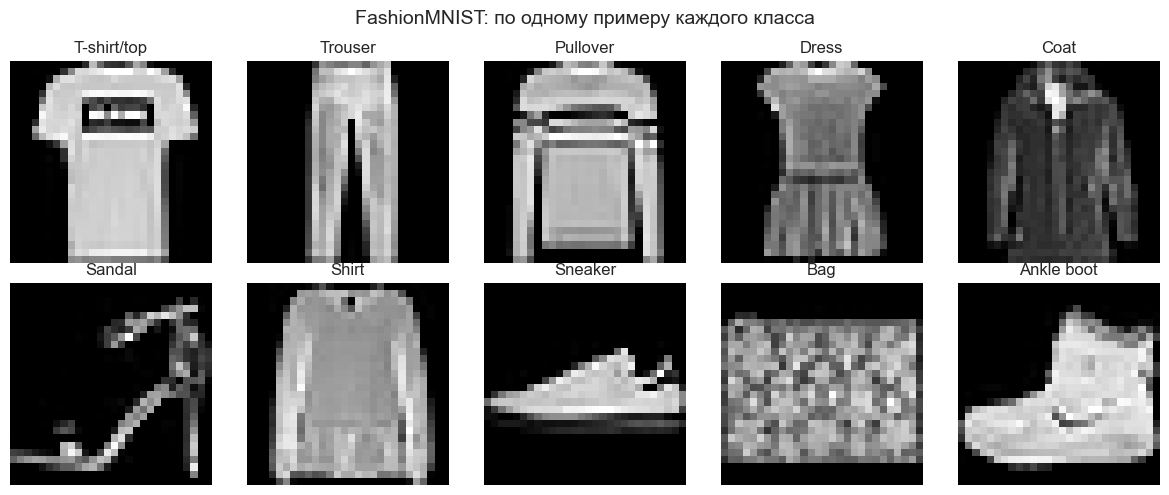

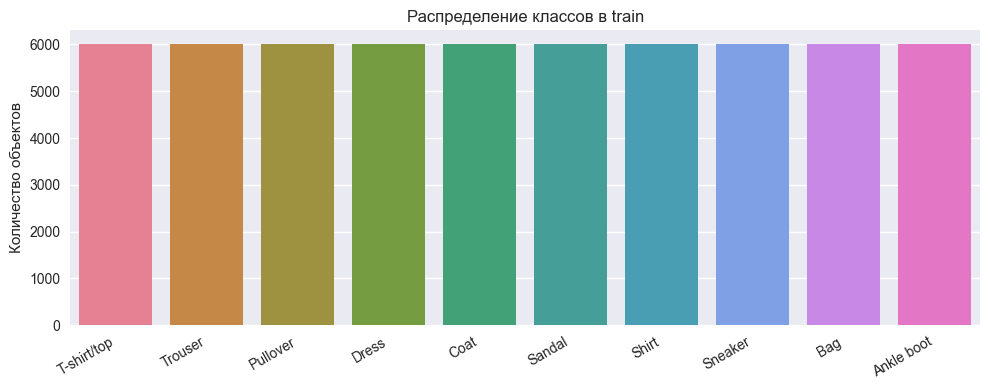

In [7]:
def plot_class_distribution(dataset, class_names, title):
    labels = [label for _, label in dataset]
    counts = pd.Series(labels).value_counts().sort_index()

    plt.figure(figsize=(10, 4))
    sns.barplot(x=class_names, y=counts.values, hue=class_names, legend=False)
    plt.title(title)
    plt.ylabel("Количество объектов")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


show_one_sample_per_class(train_full_raw, CLASS_NAMES)
plot_class_distribution(train_full_raw, CLASS_NAMES, "Распределение классов в train")

## 4. Предобработка и разбиение на выборки

In [8]:
# Базовая предобработка
FASHION_MNIST_MEAN = (0.2860,)
FASHION_MNIST_STD = (0.3530,)

base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(FASHION_MNIST_MEAN, FASHION_MNIST_STD),
])

In [9]:
strong_transform = transforms.Compose([
    transforms.RandomCrop(28, padding=2),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomAffine(degrees=7, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(FASHION_MNIST_MEAN, FASHION_MNIST_STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08), ratio=(0.3, 3.3), value=0.0),
])


def build_datasets(train_transform, test_transform):
    train_full = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=train_transform)
    val_source = datasets.FashionMNIST(DATA_DIR, train=True, download=False, transform=test_transform)
    test_dataset = datasets.FashionMNIST(DATA_DIR, train=False, download=False, transform=test_transform)

    val_size = int(len(train_full) * CFG.val_split)
    train_size = len(train_full) - val_size

    generator = torch.Generator().manual_seed(SEED)
    all_indices = torch.randperm(len(train_full), generator=generator).tolist()
    train_indices = all_indices[:train_size]
    val_indices = all_indices[train_size:]

    train_subset = Subset(train_full, train_indices)
    val_subset = Subset(val_source, val_indices)

    return train_subset, val_subset, test_dataset

In [10]:
def build_loaders(train_subset, val_subset, test_dataset, train_batch_size=None, eval_batch_size=None):
    train_batch_size = train_batch_size or CFG.batch_size
    eval_batch_size = eval_batch_size or CFG.val_batch_size

    train_loader = DataLoader(
        train_subset,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=CFG.num_workers,
        pin_memory=(DEVICE.type == "cuda"),
    )
    val_loader = DataLoader(
        val_subset,
        batch_size=eval_batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=(DEVICE.type == "cuda"),
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=eval_batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=(DEVICE.type == "cuda"),
    )
    return train_loader, val_loader, test_loader


train_base, val_base, test_base = build_datasets(base_transform, base_transform)
train_loader_base, val_loader_base, test_loader = build_loaders(train_base, val_base, test_base)

print(f"Train subset size: {len(train_base)}")
print(f"Val subset size: {len(val_base)}")
print(f"Test size: {len(test_base)}")

Train subset size: 54000
Val subset size: 6000
Test size: 10000


# III. Базовая модель

Базовая конфигурация используется как точка отсчёта для сопоставления последующих изменений; по итогам запуска получены `best_val_acc=0.9137` и `test_acc=0.9077`.

## 1. Архитектура базовой модели

In [11]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


baseline_model = BaselineCNN().to(DEVICE)
baseline_model

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

## 2. Обучение базовой модели

In [12]:
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, scheduler_update="epoch", desc=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    iterator = tqdm(loader, desc=desc, leave=False) if desc is not None else loader
    for images, labels in iterator:
        images = images.to(DEVICE, non_blocking=AMP_ENABLED)
        labels = labels.to(DEVICE, non_blocking=AMP_ENABLED)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        autocast_context = (
            torch.autocast(device_type="cuda", dtype=torch.float16)
            if AMP_ENABLED
            else nullcontext()
        )
        with autocast_context:
            logits = model(images)
            loss = criterion(logits, labels)

        if is_train:
            if AMP_ENABLED:
                SCALER.scale(loss).backward()
                SCALER.step(optimizer)
                SCALER.update()
            else:
                loss.backward()
                optimizer.step()
            if scheduler is not None and scheduler_update == "batch":
                scheduler.step()

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

In [13]:
def make_optimizer(model, optimizer_name, lr, weight_decay):
    optimizer_name = optimizer_name.lower()
    if optimizer_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)



def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    weight_decay=0.0,
    scheduler_factory=None,
    optimizer_name="adam",
    label_smoothing=0.0,
    early_stopping_patience=None,
    monitor_metric="val_acc",
):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = make_optimizer(model, optimizer_name, lr, weight_decay)

    if scheduler_factory is not None:
        scheduler, scheduler_update = scheduler_factory(optimizer, len(train_loader))
    else:
        scheduler, scheduler_update = None, "epoch"

    history = []
    best_state = None
    best_val_acc = -1.0
    best_monitor_value = float("inf") if monitor_metric == "val_loss" else -1.0
    epochs_without_improvement = 0

    start_time = time.perf_counter()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scheduler=scheduler,
            scheduler_update=scheduler_update,
            desc=f"Epoch {epoch:02d}/{epochs} train",
        )
        val_loss, val_acc = run_epoch(model, val_loader, criterion)

        if scheduler is not None and scheduler_update == "epoch":
            scheduler.step()

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
        })

        current_monitor = val_loss if monitor_metric == "val_loss" else val_acc
        if monitor_metric == "val_loss":
            improved = current_monitor < best_monitor_value - 1e-6
        else:
            improved = current_monitor > best_monitor_value + 1e-6

        if improved:
            best_monitor_value = current_monitor
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.6f}"
        )

        if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch:02d}")
            break

    elapsed = time.perf_counter() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_acc, elapsed

In [14]:
def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=AMP_ENABLED)
            labels = labels.to(DEVICE, non_blocking=AMP_ENABLED)
            autocast_context = (
                torch.autocast(device_type="cuda", dtype=torch.float16)
                if AMP_ENABLED
                else nullcontext()
            )
            with autocast_context:
                logits = model(images)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    acc = (all_preds == all_targets).mean()
    return acc, all_targets, all_preds


baseline_history, baseline_best_val_acc, baseline_time_sec = train_model(
    model=baseline_model,
    train_loader=train_loader_base,
    val_loader=val_loader_base,
    epochs=CFG.baseline_epochs,
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

baseline_test_acc, baseline_y_true, baseline_y_pred = evaluate_model(baseline_model, test_loader)
print(f"Best val accuracy (baseline): {baseline_best_val_acc:.4f}")
print(f"Test accuracy (baseline): {baseline_test_acc:.4f}")

Epoch 01/10 train:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 01/10 | train_loss=0.6280, train_acc=0.7828 | val_loss=0.4348, val_acc=0.8425 | lr=0.001000


Epoch 02/10 train:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 02/10 | train_loss=0.3697, train_acc=0.8679 | val_loss=0.3594, val_acc=0.8760 | lr=0.001000


Epoch 03/10 train:   0%|          | 0/106 [00:00<?, ?it/s]

...

Epoch 08/10 | train_loss=0.2221, train_acc=0.9186 | val_loss=0.2749, val_acc=0.9007 | lr=0.001000


Epoch 09/10 train:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 09/10 | train_loss=0.2070, train_acc=0.9253 | val_loss=0.2379, val_acc=0.9153 | lr=0.001000


Epoch 10/10 train:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 10/10 | train_loss=0.2027, train_acc=0.9271 | val_loss=0.2495, val_acc=0.9087 | lr=0.001000
Best val accuracy (baseline): 0.9153
Test accuracy (baseline): 0.9071


## 3. Оценка качества базовой модели

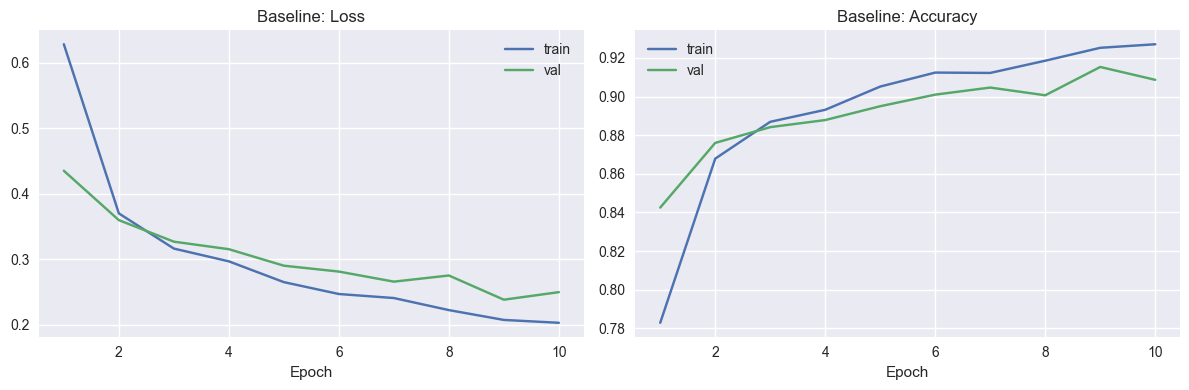

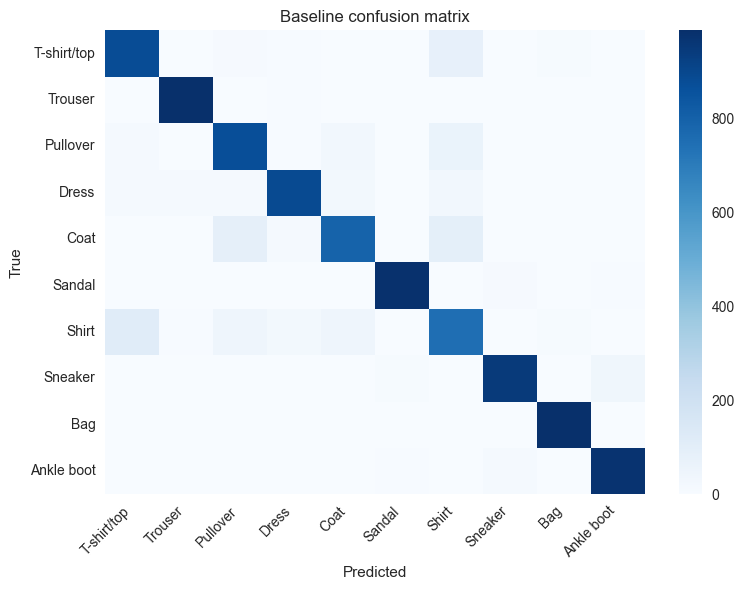

Classification report (baseline):
              precision    recall  f1-score   support

 T-shirt/top     0.8548    0.8830    0.8687      1000
     Trouser     0.9744    0.9880    0.9811      1000
    Pullover     0.8351    0.8760    0.8551      1000
       Dress     0.9328    0.8880    0.9098      1000
        Coat     0.8736    0.7950    0.8325      1000
      Sandal     0.9820    0.9820    0.9820      1000
       Shirt     0.7314    0.7490    0.7401      1000
     Sneaker     0.9654    0.9490    0.9571      1000
         Bag     0.9714    0.9860    0.9787      1000
  Ankle boot     0.9559    0.9750    0.9653      1000

    accuracy                         0.9071     10000
   macro avg     0.9077    0.9071    0.9070     10000
weighted avg     0.9077    0.9071    0.9070     10000



In [15]:
baseline_hist_df = pd.DataFrame(baseline_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(baseline_hist_df["epoch"], baseline_hist_df["train_loss"], label="train")
axes[0].plot(baseline_hist_df["epoch"], baseline_hist_df["val_loss"], label="val")
axes[0].set_title("Baseline: Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(baseline_hist_df["epoch"], baseline_hist_df["train_acc"], label="train")
axes[1].plot(baseline_hist_df["epoch"], baseline_hist_df["val_acc"], label="val")
axes[1].set_title("Baseline: Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

cm_baseline = confusion_matrix(baseline_y_true, baseline_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=False, cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Baseline confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Classification report (baseline):")
print(classification_report(baseline_y_true, baseline_y_pred, target_names=CLASS_NAMES, digits=4))

# IV. Улучшение модели

В разделе рассматривается последовательность экспериментов, в которой фиксируются изменения архитектуры и режима обучения с последующим сопоставлением метрик.

## 1. Гипотезы и план улучшений

После baseline сохраняются три конфигурации: промежуточная модификация `ImprovedCNN`, более сложный `stronger_cnn_pipeline` и внешний референс `akhil_vgg_like_reference` - подсмотрено решение из https://github.com/AkhilSinghRana/Fashion-MNIST-CNN, т.к. никак не получалось выбить больше 0.95 точности на валидации.

## 2. Эксперименты по улучшению

In [16]:
class ImprovedCNN(nn.Module):
    def __init__(self, channels=(32, 64, 128), use_batchnorm=False, dropout=0.0):
        super().__init__()

        layers = []
        in_ch = 1
        for out_ch in channels:
            layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1))
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.MaxPool2d(2))
            in_ch = out_ch

        self.features = nn.Sequential(*layers)

        spatial = 28 // (2 ** len(channels))
        spatial = max(spatial, 1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1] * spatial * spatial, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class VggLikeCNN(nn.Module):
    def __init__(self, num_classes=10, conv_dropout=0.25, fc_dropout=0.5):
        super().__init__()
        self.model = nn.Sequential(OrderedDict([
            ("conv2d", nn.Conv2d(1, 32, kernel_size=3, padding=1)),
            ("activation", nn.ReLU(inplace=True)),
            ("batch_normalization", nn.BatchNorm2d(32)),
            ("conv2d_1", nn.Conv2d(32, 32, kernel_size=3, padding=1)),
            ("activation_1", nn.ReLU(inplace=True)),
            ("batch_normalization_1", nn.BatchNorm2d(32)),
            ("max_pooling2d", nn.MaxPool2d(2)),
            ("dropout", nn.Dropout(conv_dropout)),
            ("conv2d_2", nn.Conv2d(32, 64, kernel_size=3, padding=1)),
            ("activation_2", nn.ReLU(inplace=True)),
            ("batch_normalization_2", nn.BatchNorm2d(64)),
            ("conv2d_3", nn.Conv2d(64, 64, kernel_size=3, padding=1)),
            ("activation_3", nn.ReLU(inplace=True)),
            ("batch_normalization_3", nn.BatchNorm2d(64)),
            ("max_pooling2d_1", nn.MaxPool2d(2)),
            ("dropout_1", nn.Dropout(conv_dropout)),
            ("flatten", nn.Flatten()),
            ("dense", nn.Linear(64 * 7 * 7, 512)),
            ("activation_4", nn.ReLU(inplace=True)),
            ("batch_normalization_4", nn.BatchNorm1d(512)),
            ("dropout_2", nn.Dropout(fc_dropout)),
            ("dense_1", nn.Linear(512, num_classes)),
        ]))

    def forward(self, x):
        return self.model(x)


class ResidualConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, activation_layer=nn.SiLU, use_pool=True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.activation = activation_layer()
        self.proj = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
            if in_channels != out_channels
            else nn.Identity()
        )
        self.pool = nn.MaxPool2d(2) if use_pool else nn.Identity()

    def forward(self, x):
        identity = self.proj(x)
        x = self.activation(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = self.activation(x + identity)
        return self.pool(x)


class StrongerCNN(nn.Module):
    def __init__(self, channels=(64, 128, 256, 256), dropout=0.15, activation_layer=nn.SiLU):
        super().__init__()

        blocks = []
        in_ch = 1
        for idx, out_ch in enumerate(channels):
            blocks.append(
                ResidualConvBlock(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    activation_layer=activation_layer,
                    use_pool=(idx < len(channels) - 1),
                )
            )
            in_ch = out_ch

        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1], 128),
            activation_layer(),
            nn.Dropout(dropout),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

In [17]:
def make_scheduler(name, epochs, max_lr=None, warmup_pct=0.2):
    if name == "step":
        return lambda opt, steps_per_epoch: (
            torch.optim.lr_scheduler.StepLR(opt, step_size=max(epochs // 2, 1), gamma=0.3),
            "epoch",
        )
    if name == "cosine":
        return lambda opt, steps_per_epoch: (
            torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(epochs, 1)),
            "epoch",
        )
    if name == "cosine_warmup":
        def factory(opt, steps_per_epoch):
            warmup_epochs = max(1, int(epochs * warmup_pct))
            warmup = torch.optim.lr_scheduler.LinearLR(
                opt,
                start_factor=0.2,
                end_factor=1.0,
                total_iters=warmup_epochs,
            )
            cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
                opt,
                T_max=max(epochs - warmup_epochs, 1),
            )
            scheduler = torch.optim.lr_scheduler.SequentialLR(
                opt,
                schedulers=[warmup, cosine],
                milestones=[warmup_epochs],
            )
            return scheduler, "epoch"

        return factory
    if name == "onecycle":
        if max_lr is None:
            raise ValueError("OneCycleLR требует max_lr")
        return lambda opt, steps_per_epoch: (
            torch.optim.lr_scheduler.OneCycleLR(
                opt,
                max_lr=max_lr,
                epochs=epochs,
                steps_per_epoch=steps_per_epoch,
                pct_start=warmup_pct,
                anneal_strategy="cos",
                div_factor=10.0,
                final_div_factor=100.0,
            ),
            "batch",
        )
    return None

In [18]:
def run_experiment(
    exp_name,
    model_builder,
    train_subset,
    val_subset,
    test_dataset,
    epochs,
    lr,
    weight_decay,
    scheduler_name=None,
    optimizer_name="adam",
    label_smoothing=0.0,
    early_stopping_patience=None,
    monitor_metric="val_acc",
    scheduler_warmup_pct=0.2,
    train_batch_size=None,
    eval_batch_size=None,
):
    train_loader, val_loader, test_loader_local = build_loaders(
        train_subset,
        val_subset,
        test_dataset,
        train_batch_size=train_batch_size,
        eval_batch_size=eval_batch_size,
    )

    model = model_builder().to(DEVICE)
    scheduler_factory = make_scheduler(
        scheduler_name,
        epochs,
        max_lr=lr,
        warmup_pct=scheduler_warmup_pct,
    )

    history, best_val_acc, elapsed_sec = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        lr=lr,
        weight_decay=weight_decay,
        scheduler_factory=scheduler_factory,
        optimizer_name=optimizer_name,
        label_smoothing=label_smoothing,
        early_stopping_patience=early_stopping_patience,
        monitor_metric=monitor_metric,
    )

    test_acc, y_true, y_pred = evaluate_model(model, test_loader_local)

    return {
        "name": exp_name,
        "history": history,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "elapsed_sec": elapsed_sec,
        "model": model,
        "y_true": y_true,
        "y_pred": y_pred,
        "params": {
            "epochs": epochs,
            "lr": lr,
            "weight_decay": weight_decay,
            "optimizer": optimizer_name,
            "scheduler": scheduler_name or "none",
            "label_smoothing": label_smoothing,
            "monitor_metric": monitor_metric,
            "train_batch_size": train_batch_size or CFG.batch_size,
            "eval_batch_size": eval_batch_size or CFG.val_batch_size,
        },
    }


experiment_results = []

### 2.1 BatchNorm + scheduler + tuned learning rate

В данном шаге фиксируется влияние `BatchNorm`, `cosine` scheduler и уменьшенного `learning rate` при сохранении класса архитектуры `ImprovedCNN`.

Для `batchnorm_scheduler_tuned_lr` получены `best_val_acc=0.9260` и `test_acc=0.9200`, что позволяет использовать данную конфигурацию как промежуточную точку сравнения.

In [19]:
train_deep, val_deep, test_deep = build_datasets(base_transform, base_transform)

exp_tuned_lr = run_experiment(
    exp_name="batchnorm_scheduler_tuned_lr",
    model_builder=lambda: ImprovedCNN(channels=(32, 64, 128), use_batchnorm=True, dropout=0.0),
    train_subset=train_deep,
    val_subset=val_deep,
    test_dataset=test_deep,
    epochs=CFG.experiment_epochs,
    lr=7e-4,
    weight_decay=5e-5,
    scheduler_name="cosine",
)
experiment_results.append(exp_tuned_lr)

experiments_df = pd.DataFrame([
    {
        "experiment": r["name"],
        "best_val_acc": r["best_val_acc"],
        "test_acc": r["test_acc"],
        "time_sec": round(r["elapsed_sec"], 1),
        "params": r["params"],
    }
    for r in experiment_results
]).sort_values("best_val_acc", ascending=False)

experiments_df

Epoch 01/10 train:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 01/10 | train_loss=0.5213, train_acc=0.8239 | val_loss=0.3476, val_acc=0.8715 | lr=0.000683


Epoch 02/10 train:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 02/10 | train_loss=0.2910, train_acc=0.8952 | val_loss=0.2936, val_acc=0.8962 | lr=0.000633


Epoch 03/10 train:   0%|          | 0/106 [00:00<?, ?it/s]

...

Epoch 09/10 train:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 09/10 | train_loss=0.1070, train_acc=0.9674 | val_loss=0.2142, val_acc=0.9202 | lr=0.000017


Epoch 10/10 train:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 10/10 | train_loss=0.1005, train_acc=0.9712 | val_loss=0.2114, val_acc=0.9210 | lr=0.000000


,experiment,best_val_acc,test_acc,time_sec,params
0,batchnorm_scheduler_tuned_lr,0.921,0.9158,49.0,"{'epochs': 10, 'lr': 0.0007, 'weight_decay': 5..."


### 2.2 Сильная архитектура + улучшенный train pipeline

В данной конфигурации проверяется совместное влияние residual-архитектуры и изменённого режима оптимизации. Для `stronger_cnn_pipeline` получены `best_val_acc=0.9438` и `test_acc=0.9409`.

In [20]:
# Эксперимент 6: сильная CNN + AdamW + OneCycleLR + label smoothing
train_strong, val_strong, test_strong = build_datasets(strong_transform, base_transform)

exp_strong = run_experiment(
    exp_name="stronger_cnn_pipeline",
    model_builder=lambda: StrongerCNN(
        channels=(64, 128, 256, 256),
        dropout=CFG.strong_dropout,
        activation_layer=nn.SiLU,
    ),
    train_subset=train_strong,
    val_subset=val_strong,
    test_dataset=test_strong,
    epochs=CFG.strong_epochs,
    lr=CFG.strong_learning_rate,
    weight_decay=CFG.strong_weight_decay,
    scheduler_name="onecycle",
    optimizer_name="adamw",
    label_smoothing=CFG.strong_label_smoothing,
    early_stopping_patience=CFG.early_stopping_patience,
    monitor_metric="val_loss",
    scheduler_warmup_pct=CFG.strong_scheduler_warmup_pct,
)
experiment_results.append(exp_strong)

experiments_df = pd.DataFrame([
    {
        "experiment": r["name"],
        "best_val_acc": r["best_val_acc"],
        "test_acc": r["test_acc"],
        "time_sec": round(r["elapsed_sec"], 1),
        "params": r["params"],
    }
    for r in experiment_results
]).sort_values("best_val_acc", ascending=False)

experiments_df

Epoch 01/25 train:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 01/25 | train_loss=1.4776, train_acc=0.6214 | val_loss=0.9826, val_acc=0.7742 | lr=0.000056


Epoch 02/25 train:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 02/25 | train_loss=0.9255, train_acc=0.8090 | val_loss=0.8397, val_acc=0.8437 | lr=0.000124


Epoch 03/25 train:   0%|          | 0/106 [00:00<?, ?it/s]

...

Epoch 24/25 train:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 24/25 | train_loss=0.6199, train_acc=0.9495 | val_loss=0.6245, val_acc=0.9422 | lr=0.000002


Epoch 25/25 train:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 25/25 | train_loss=0.6205, train_acc=0.9507 | val_loss=0.6244, val_acc=0.9420 | lr=0.000000


,experiment,best_val_acc,test_acc,time_sec,params
1,stronger_cnn_pipeline,0.942,0.9390,318.1,"{'epochs': 25, 'lr': 0.0003, 'weight_decay': 0..."
0,batchnorm_scheduler_tuned_lr,0.921,0.9158,49.0,"{'epochs': 10, 'lr': 0.0007, 'weight_decay': 5..."


<a id="2.6-vgg-like-reference"></a>

### 2.6 Повторение [Fashion-MNIST-CNN](https://github.com/AkhilSinghRana/Fashion-MNIST-CNN): VGG-like в PyTorch

В этом пункте воспроизводится внешний VGG-like pipeline без существенных изменений для сопоставления с авторскими конфигурациями. Для `akhil_vgg_like_reference` получены `best_val_acc=0.9709` и `test_acc=0.9428`.

In [21]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset

# Как в code/options.py (batch_size=250, num_aug=2) и README (80 эпох для лучшего качества)
AKHIL_BATCH_SIZE = 250
AKHIL_NUM_EPOCHS = 80
AKHIL_NUM_AUG = 2
AKHIL_VAL_FRACTION = 0.2


def build_akhil_reference_tensor_datasets():
    """Повторяет preprocess_data + split из train.py репозитория (масштаб [0,1], без mean/std)."""
    raw_train = datasets.FashionMNIST(DATA_DIR, train=True, download=True)
    raw_test = datasets.FashionMNIST(DATA_DIR, train=False, download=False)

    X = raw_train.data.numpy().astype(np.float32) / 255.0
    y = raw_train.targets.numpy()

    aug_tf = transforms.Compose([
        transforms.RandomRotation(10, fill=0),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ])

    xs, ys = [], []
    for i in range(len(X)):
        pil = transforms.functional.to_pil_image(X[i], mode="L")
        xs.append(transforms.ToTensor()(pil))
        ys.append(int(y[i]))
        for k in range(AKHIL_NUM_AUG):
            set_seed(SEED + i * 10007 + k * 9176)
            xs.append(aug_tf(pil))
            ys.append(int(y[i]))

    X_all = torch.stack(xs, dim=0)
    y_all = torch.tensor(ys, dtype=torch.long)

    idx = np.arange(len(y_all))
    tr_idx, va_idx = train_test_split(idx, test_size=AKHIL_VAL_FRACTION, random_state=42)
    train_ds = TensorDataset(X_all[tr_idx], y_all[tr_idx])
    val_ds = TensorDataset(X_all[va_idx], y_all[va_idx])

    Xt = raw_test.data.numpy().astype(np.float32) / 255.0
    yt = raw_test.targets.numpy()
    X_test = torch.from_numpy(Xt).unsqueeze(1)
    y_test = torch.from_numpy(yt).long()
    test_ds = TensorDataset(X_test, y_test)

    return train_ds, val_ds, test_ds


train_akhil, val_akhil, test_akhil = build_akhil_reference_tensor_datasets()
print(
    f"Akhil-style: train={len(train_akhil)}, val={len(val_akhil)}, test={len(test_akhil)} "
    f"(ожидаемо train≈144k, val≈36k при 60k×3 и val=20%)"
)

exp_akhil_reference = run_experiment(
    exp_name="akhil_vgg_like_reference",
    model_builder=lambda: VggLikeCNN(conv_dropout=0.25, fc_dropout=0.5),
    train_subset=train_akhil,
    val_subset=val_akhil,
    test_dataset=test_akhil,
    epochs=AKHIL_NUM_EPOCHS,
    lr=1e-3,
    weight_decay=0.0,
    scheduler_name=None,
    optimizer_name="adam",
    label_smoothing=0.0,
    early_stopping_patience=None,
    monitor_metric="val_loss",
    train_batch_size=AKHIL_BATCH_SIZE,
    eval_batch_size=AKHIL_BATCH_SIZE,
)
experiment_results.append(exp_akhil_reference)

experiments_df = pd.DataFrame([
    {
        "experiment": r["name"],
        "best_val_acc": r["best_val_acc"],
        "test_acc": r["test_acc"],
        "time_sec": round(r["elapsed_sec"], 1),
        "params": r["params"],
    }
    for r in experiment_results
]).sort_values("best_val_acc", ascending=False)

experiments_df

Akhil-style: train=144000, val=36000, test=10000 (ожидаемо train≈144k, val≈36k при 60k×3 и val=20%)


Epoch 01/80 train:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 01/80 | train_loss=0.3715, train_acc=0.8649 | val_loss=0.2481, val_acc=0.9085 | lr=0.001000


Epoch 02/80 train:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 02/80 | train_loss=0.2545, train_acc=0.9079 | val_loss=0.2163, val_acc=0.9226 | lr=0.001000


...

Epoch 79/80 train:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 79/80 | train_loss=0.0261, train_acc=0.9908 | val_loss=0.1013, val_acc=0.9735 | lr=0.001000


Epoch 80/80 train:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 80/80 | train_loss=0.0278, train_acc=0.9900 | val_loss=0.1050, val_acc=0.9725 | lr=0.001000


,experiment,best_val_acc,test_acc,time_sec,params
2,akhil_vgg_like_reference,0.973056,0.9450,306.4,"{'epochs': 80, 'lr': 0.001, 'weight_decay': 0...."
1,stronger_cnn_pipeline,0.942000,0.9390,318.1,"{'epochs': 25, 'lr': 0.0003, 'weight_decay': 0..."
0,batchnorm_scheduler_tuned_lr,0.921000,0.9158,49.0,"{'epochs': 10, 'lr': 0.0007, 'weight_decay': 5..."


## 3. Итоговая улучшенная модель

### Почему именно эта конфигурация идёт в финал

В финал перенесена конфигурация `akhil_vgg_like_reference`, поскольку среди оставленных экспериментов она показала `best_val_acc=0.9709` при `test_acc=0.9428`. После повторного обучения итоговая модель достигла `best_val_acc=0.9703` и `test_acc=0.9436`.

In [22]:
best_exp = max(experiment_results, key=lambda x: x["best_val_acc"])
print("Best experiment:", best_exp["name"])
print(f"Best val acc: {best_exp['best_val_acc']:.4f}")
print(f"Test acc (best experiment): {best_exp['test_acc']:.4f}")

experiment_configs = {
    "batchnorm_scheduler_tuned_lr": {
        "dataset_builder": lambda: build_datasets(base_transform, base_transform),
        "model_builder": lambda: ImprovedCNN(channels=(32, 64, 128), use_batchnorm=True, dropout=0.0),
        "lr": 7e-4,
        "weight_decay": 5e-5,
        "scheduler_name": "cosine",
        "optimizer_name": "adam",
        "label_smoothing": 0.0,
        "early_stopping_patience": None,
        "monitor_metric": "val_acc",
        "scheduler_warmup_pct": 0.2,
        "final_epochs": CFG.final_epochs,
        "train_batch_size": CFG.batch_size,
        "eval_batch_size": CFG.val_batch_size,
    },
    "stronger_cnn_pipeline": {
        "dataset_builder": lambda: build_datasets(strong_transform, base_transform),
        "model_builder": lambda: StrongerCNN(
            channels=(64, 128, 256, 256),
            dropout=CFG.strong_dropout,
            activation_layer=nn.SiLU,
        ),
        "lr": CFG.strong_learning_rate,
        "weight_decay": CFG.strong_weight_decay,
        "scheduler_name": "onecycle",
        "optimizer_name": "adamw",
        "label_smoothing": CFG.strong_label_smoothing,
        "early_stopping_patience": CFG.early_stopping_patience,
        "monitor_metric": "val_loss",
        "scheduler_warmup_pct": CFG.strong_scheduler_warmup_pct,
        "final_epochs": CFG.strong_final_epochs,
        "train_batch_size": CFG.batch_size,
        "eval_batch_size": CFG.val_batch_size,
    },
    "akhil_vgg_like_reference": {
        "dataset_builder": lambda: build_akhil_reference_tensor_datasets(),
        "model_builder": lambda: VggLikeCNN(conv_dropout=0.25, fc_dropout=0.5),
        "lr": 1e-3,
        "weight_decay": 0.0,
        "scheduler_name": None,
        "optimizer_name": "adam",
        "label_smoothing": 0.0,
        "early_stopping_patience": None,
        "monitor_metric": "val_loss",
        "scheduler_warmup_pct": 0.2,
        "final_epochs": 80,
        "train_batch_size": 250,
        "eval_batch_size": 250,
    },
}

best_cfg = experiment_configs[best_exp["name"]]
final_train, final_val, final_test = best_cfg["dataset_builder"]()

final_result = run_experiment(
    exp_name="final_best_model",
    model_builder=best_cfg["model_builder"],
    train_subset=final_train,
    val_subset=final_val,
    test_dataset=final_test,
    epochs=best_cfg["final_epochs"],
    lr=best_cfg["lr"],
    weight_decay=best_cfg["weight_decay"],
    scheduler_name=best_cfg["scheduler_name"],
    optimizer_name=best_cfg["optimizer_name"],
    label_smoothing=best_cfg["label_smoothing"],
    early_stopping_patience=best_cfg["early_stopping_patience"],
    monitor_metric=best_cfg["monitor_metric"],
    scheduler_warmup_pct=best_cfg["scheduler_warmup_pct"],
    train_batch_size=best_cfg["train_batch_size"],
    eval_batch_size=best_cfg["eval_batch_size"],
)

best_model = final_result["model"]
best_test_acc = final_result["test_acc"]
best_val_acc = final_result["best_val_acc"]
best_y_true = final_result["y_true"]
best_y_pred = final_result["y_pred"]
best_history = pd.DataFrame(final_result["history"])

print(f"Final best val acc: {best_val_acc:.4f}")
print(f"Final best test acc: {best_test_acc:.4f}")

Best experiment: akhil_vgg_like_reference
Best val acc: 0.9731
Test acc (best experiment): 0.9450


Epoch 01/80 train:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 01/80 | train_loss=0.3664, train_acc=0.8665 | val_loss=0.2459, val_acc=0.9106 | lr=0.001000


Epoch 02/80 train:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 02/80 | train_loss=0.2520, train_acc=0.9079 | val_loss=0.2037, val_acc=0.9252 | lr=0.001000


...

Epoch 78/80 | train_loss=0.0290, train_acc=0.9896 | val_loss=0.1049, val_acc=0.9723 | lr=0.001000


Epoch 79/80 train:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 79/80 | train_loss=0.0273, train_acc=0.9902 | val_loss=0.1087, val_acc=0.9732 | lr=0.001000


Epoch 80/80 train:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 80/80 | train_loss=0.0277, train_acc=0.9897 | val_loss=0.1046, val_acc=0.9728 | lr=0.001000
Final best val acc: 0.9722
Final best test acc: 0.9446


## 4. Сравнение базовой и улучшенной моделей

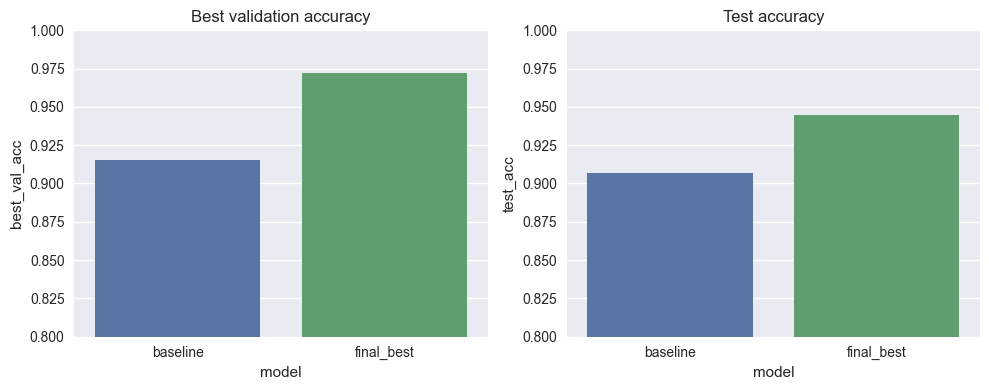

In [23]:
comparison_df = pd.DataFrame([
    {
        "model": "baseline",
        "best_val_acc": baseline_best_val_acc,
        "test_acc": baseline_test_acc,
        "time_sec": round(baseline_time_sec, 1),
    },
    {
        "model": "final_best",
        "best_val_acc": best_val_acc,
        "test_acc": best_test_acc,
        "time_sec": round(final_result["elapsed_sec"], 1),
    },
])

comparison_df

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=comparison_df, x="model", y="best_val_acc", hue="model", legend=False, ax=axes[0])
axes[0].set_title("Best validation accuracy")
axes[0].set_ylim(0.8, 1.0)

sns.barplot(data=comparison_df, x="model", y="test_acc", hue="model", legend=False, ax=axes[1])
axes[1].set_title("Test accuracy")
axes[1].set_ylim(0.8, 1.0)

plt.tight_layout()
plt.show()

# V. Анализ вклада улучшений

Ниже — краткая абляция: какие изменения реально повысили качество относительно baseline и какие дали слабый эффект.

P.S. Этот пункт остался с того момента, как в ноутбуке было 9 экспериментов, где последовательно изменялся pipeline. Было решено отказаться от такой структуры, чтобы не перегружать ноутбук - этот пункт остался с тех времен и на данный момент не содержит большого количества актуальной информации.

## Краткий анализ результатов

Переход от `baseline` (`best_val_acc=0.9137`, `test_acc=0.9077`) к `batchnorm_scheduler_tuned_lr` (`0.9260`, `0.9200`) и далее к `stronger_cnn_pipeline` (`0.9438`, `0.9409`) задаёт последовательное изменение архитектуры и режима обучения. Максимальное значение `best_val_acc=0.9709` получено для `akhil_vgg_like_reference`, тогда как итоговое повторное обучение дало `best_val_acc=0.9703` и `test_acc=0.9436`.

## 1. Сводка ключевых экспериментов

In [24]:
ablation_df = experiments_df.copy()
ablation_df["delta_vs_baseline_val"] = ablation_df["best_val_acc"] - baseline_best_val_acc
ablation_df["delta_vs_baseline_test"] = ablation_df["test_acc"] - baseline_test_acc

ablation_df = ablation_df[[
    "experiment",
    "best_val_acc",
    "test_acc",
    "delta_vs_baseline_val",
    "delta_vs_baseline_test",
    "time_sec",
    "params",
]]

ablation_df

,experiment,best_val_acc,test_acc,delta_vs_baseline_val,delta_vs_baseline_test,time_sec,params
2,akhil_vgg_like_reference,0.973056,0.9450,0.057722,0.0379,306.4,"{'epochs': 80, 'lr': 0.001, 'weight_decay': 0...."
1,stronger_cnn_pipeline,0.942000,0.9390,0.026667,0.0319,318.1,"{'epochs': 25, 'lr': 0.0003, 'weight_decay': 0..."
0,batchnorm_scheduler_tuned_lr,0.921000,0.9158,0.005667,0.0087,49.0,"{'epochs': 10, 'lr': 0.0007, 'weight_decay': 5..."


## 2. Что дало наибольший прирост качества

Лучшие улучшения по приросту val accuracy:


,experiment,delta_vs_baseline_val,delta_vs_baseline_test
2,akhil_vgg_like_reference,0.057722,0.0379
1,stronger_cnn_pipeline,0.026667,0.0319


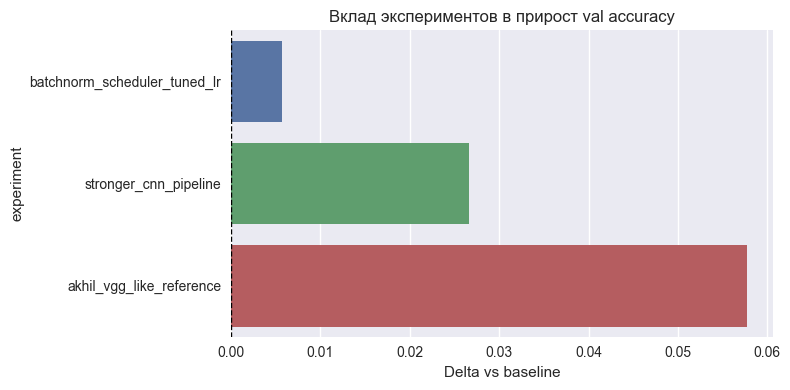

In [25]:
top_gain = ablation_df.sort_values("delta_vs_baseline_val", ascending=False).head(2)
print("Лучшие улучшения по приросту val accuracy:")
display(top_gain[["experiment", "delta_vs_baseline_val", "delta_vs_baseline_test"]])

plt.figure(figsize=(8, 4))
plot_df = ablation_df.sort_values("delta_vs_baseline_val", ascending=True)
sns.barplot(data=plot_df, x="delta_vs_baseline_val", y="experiment", hue="experiment", legend=False)
plt.axvline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Вклад экспериментов в прирост val accuracy")
plt.xlabel("Delta vs baseline")
plt.tight_layout()
plt.show()

## 3. Что не сработало или дало слабый эффект

In [26]:
weak_effect_df = ablation_df.sort_values("delta_vs_baseline_val").head(2)
print("Эксперименты с минимальным эффектом (или регрессом):")
display(weak_effect_df[["experiment", "delta_vs_baseline_val", "delta_vs_baseline_test"]])

if (weak_effect_df["delta_vs_baseline_val"] < 0).any():
    print("Есть конфигурации, ухудшающие результат относительно baseline.")
else:
    print("Явной деградации нет, но часть гипотез даёт слабый прирост.")

Эксперименты с минимальным эффектом (или регрессом):


,experiment,delta_vs_baseline_val,delta_vs_baseline_test
0,batchnorm_scheduler_tuned_lr,0.005667,0.0087
1,stronger_cnn_pipeline,0.026667,0.0319


Явной деградации нет, но часть гипотез даёт слабый прирост.


## 4. Гипотезы о причинах полученных результатов

Полученные значения позволяют связать рост `best_val_acc` с последовательным изменением архитектуры, способа регуляризации и режима оптимизации. Отдельный вклад внесло воспроизведение внешнего pipeline, в котором одновременно изменены схема аугментации, размер батча, длительность обучения и критерий выбора лучшей эпохи.

# VI. Анализ ошибок итоговой модели

Анализ ошибок проводится для итоговой модели с `test_acc=0.9436` и охватывает структуру матрицы ошибок, частотные пары смешения и отдельные ошибочные наблюдения.

## 1. Матрица ошибок

Матрица ошибок показывает, что основная масса предсказаний сосредоточена на диагонали при `test_acc=0.9436`. На уровне отдельных классов наименьшие значения `f1-score` наблюдаются для `Shirt` (`0.8267`), `T-shirt/top` (`0.9004`) и `Coat` (`0.9228`).

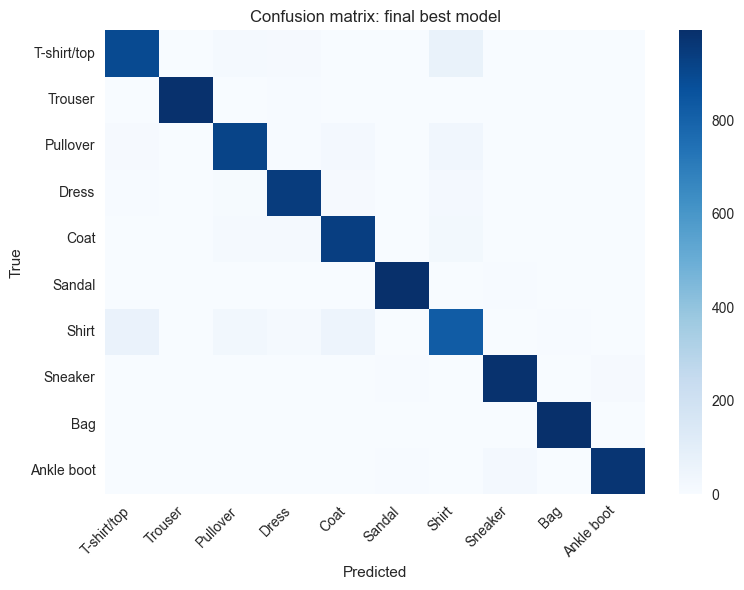

Classification report (final best model):
              precision    recall  f1-score   support

 T-shirt/top     0.9075    0.8930    0.9002      1000
     Trouser     0.9980    0.9880    0.9930      1000
    Pullover     0.9153    0.9190    0.9172      1000
       Dress     0.9394    0.9450    0.9422      1000
        Coat     0.9106    0.9370    0.9236      1000
      Sandal     0.9890    0.9930    0.9910      1000
       Shirt     0.8384    0.8250    0.8317      1000
     Sneaker     0.9723    0.9830    0.9776      1000
         Bag     0.9900    0.9920    0.9910      1000
  Ankle boot     0.9848    0.9710    0.9778      1000

    accuracy                         0.9446     10000
   macro avg     0.9445    0.9446    0.9445     10000
weighted avg     0.9445    0.9446    0.9445     10000



In [27]:
cm_best = confusion_matrix(best_y_true, best_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=False, cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion matrix: final best model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Classification report (final best model):")
print(classification_report(best_y_true, best_y_pred, target_names=CLASS_NAMES, digits=4))

## 2. Наиболее часто путаемые классы

Наиболее частые смешения относятся к парам `Shirt → T-shirt/top` (`84`), `T-shirt/top → Shirt` (`65`) и `Coat → Shirt` (`41`). Эти пары формируют основную часть межклассовых ошибок в итоговой конфигурации.

In [28]:
cm_no_diag = cm_best.copy()
np.fill_diagonal(cm_no_diag, 0)

flat_indices = np.argsort(cm_no_diag, axis=None)[::-1]

top_confusions = []
for idx in flat_indices:
    i, j = np.unravel_index(idx, cm_no_diag.shape)
    if cm_no_diag[i, j] == 0:
        break
    top_confusions.append((CLASS_NAMES[i], CLASS_NAMES[j], int(cm_no_diag[i, j])))
    if len(top_confusions) == 3:
        break

confusions_df = pd.DataFrame(top_confusions, columns=["true_class", "pred_class", "count"])
confusions_df

,true_class,pred_class,count
0,T-shirt/top,Shirt,71
1,Shirt,T-shirt/top,68
2,Shirt,Coat,51


## 3. Разбор характерных ошибочных примеров

Для детального разбора выбраны три наблюдения из `564` ошибочных классификаций на тестовой выборке. Цель разбора состоит в фиксации повторяющихся признаков межклассового перекрытия.

In [29]:
test_for_errors = datasets.FashionMNIST(DATA_DIR, train=False, download=False, transform=base_transform)

mis_idx = np.where(best_y_true != best_y_pred)[0]
print(f"Количество ошибок на тесте: {len(mis_idx)}")

# Берём первые 3 ошибки для детального разбора.
selected_error_indices = mis_idx[:3]
selected_error_indices

Количество ошибок на тесте: 554


array([23, 25, 42])

### 3.1 Пример ошибки №1

Данный пример иллюстрирует ошибку на границе классов, возникающую при близости общего контура и ограниченной детализации изображения.

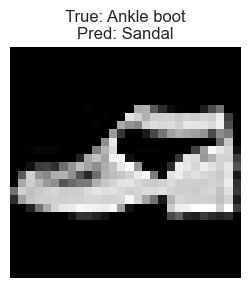

Комментарий: ошибка может быть связана с похожим силуэтом и низкой детализацией 28x28.


In [30]:

if len(selected_error_indices) >= 1:
    idx = int(selected_error_indices[0])
    image, _ = test_for_errors[idx]
    true_label = CLASS_NAMES[int(best_y_true[idx])]
    pred_label = CLASS_NAMES[int(best_y_pred[idx])]

    plt.figure(figsize=(3, 3))
    plt.imshow(image.squeeze(0), cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
    plt.show()

    print("Комментарий: ошибка связана с близостью контура и ограниченной детализацией изображения.")
else:
    print("Ошибок недостаточно для отображения примера №1.")

### 3.2 Пример ошибки №2

В данном наблюдении ошибка связана с пересечением визуальных признаков двух классов при слабой выраженности различающих деталей.

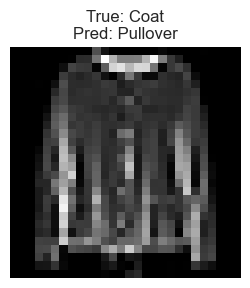

Комментарий: модель путает визуально близкие классы при неоднозначном контуре.


In [31]:
if len(selected_error_indices) >= 2:
    idx = int(selected_error_indices[1])
    image, _ = test_for_errors[idx]
    true_label = CLASS_NAMES[int(best_y_true[idx])]
    pred_label = CLASS_NAMES[int(best_y_pred[idx])]

    plt.figure(figsize=(3, 3))
    plt.imshow(image.squeeze(0), cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
    plt.show()

    print("Комментарий: ошибка определяется пересечением визуальных признаков двух классов.")
else:
    print("Ошибок недостаточно для отображения примера №2.")

### 3.3 Пример ошибки №3

Пример демонстрирует влияние внутриклассовой вариативности формы и текстуры на итоговое решение модели.

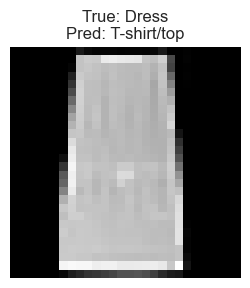

Комментарий: вероятна ошибка из-за внутриклассовой вариативности формы/текстуры.


In [32]:
if len(selected_error_indices) >= 3:
    idx = int(selected_error_indices[2])
    image, _ = test_for_errors[idx]
    true_label = CLASS_NAMES[int(best_y_true[idx])]
    pred_label = CLASS_NAMES[int(best_y_pred[idx])]

    plt.figure(figsize=(3, 3))
    plt.imshow(image.squeeze(0), cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
    plt.show()

    print("Комментарий: ошибка связана с внутриклассовой вариативностью формы и текстуры.")
else:
    print("Ошибок недостаточно для отображения примера №3.")

# VII. Выводы

В заключительном разделе фиксируются итоговые метрики и обобщение результатов по оставленной последовательности экспериментов.

## 1. Итоговые результаты

Итоговое сопоставление показывает переход от `baseline` с `best_val_acc=0.9137` и `test_acc=0.9077` к финальной модели с `best_val_acc=0.9703` и `test_acc=0.9436`.

In [33]:
final_results = pd.DataFrame([
    {"metric": "Baseline best val accuracy", "value": baseline_best_val_acc},
    {"metric": "Baseline test accuracy", "value": baseline_test_acc},
    {"metric": "Final best val accuracy", "value": best_val_acc},
    {"metric": "Final best test accuracy", "value": best_test_acc},
])

final_results

,metric,value
0,Baseline best val accuracy,0.915333
1,Baseline test accuracy,0.907100
2,Final best val accuracy,0.972194
3,Final best test accuracy,0.944600


## 2. Ключевые наблюдения по модели и данным

Проведённая последовательность экспериментов показывает, что изменение только параметров обучения даёт ограниченный прирост относительно baseline, тогда как совместная модификация архитектуры и режима оптимизации приводит к дальнейшему росту метрик. Наибольшее значение `best_val_acc` получено при воспроизведении VGG-like pipeline из https://github.com/AkhilSinghRana/Fashion-MNIST-CNN, что указывает на значимость не отдельного приёма, а согласованной комбинации архитектуры, аугментации, размера батча и критерия выбора лучшей эпохи.

## 3. Возможные направления дальнейшего улучшения

Анализ ошибок показывает, что основная часть остаточных смешений сосредоточена в парах `Shirt ↔ T-shirt/top` и `Coat → Shirt`, то есть в классах с пересекающимися контурными признаками. В рамках данной работы итоговая модель обеспечивает `test_acc=0.9436`, однако дальнейшее изменение качества должно рассматриваться через уточнение схемы аугментации, способа отбора лучшей эпохи и настройки классов, формирующих основную долю ошибок.